In [94]:
import warnings
import numpy as np
%matplotlib inline
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [95]:
Data = pd.read_csv("movies.csv", encoding='latin1')

In [96]:
Data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [97]:
Data.shape

(15509, 10)

In [98]:
Data.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [99]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [100]:
def missing_values_percent(dataframe):
    missing_values = dataframe.isna().sum()
    percentage_missing = (missing_values / len(dataframe) * 100).round(2)

    result_movie = pd.DataFrame({'Missing Values': missing_values, 'Percentage': percentage_missing})
    result_movie['Percentage'] = result_movie['Percentage'].astype(str) + '%'

    return result_movie


result = missing_values_percent(Data)
result


,Missing Values,Percentage
Name,0,0.0%
Year,528,3.4%
Duration,8269,53.32%
Genre,1877,12.1%
Rating,7590,48.94%
Votes,7589,48.93%
Director,525,3.39%
Actor 1,1617,10.43%
Actor 2,2384,15.37%
Actor 3,3144,20.27%


In [101]:
Data.drop(['Actor 2' , 'Actor 3'], axis=1, inplace=True)
Data.dropna(subset=['Duration'], inplace = True)
Data = Data[Data.isnull().sum(axis=1).sort_values(ascending=False) <=5]
missing_values_percent(Data)

,Missing Values,Percentage
Name,0,0.0%
Year,125,1.73%
Duration,0,0.0%
Genre,187,2.58%
Rating,1389,19.19%
Votes,1389,19.19%
Director,14,0.19%
Actor 1,264,3.65%


In [102]:
Data.dropna(subset=['Rating', 'Votes'], inplace=True)
director_description = Data['Director'].describe()

director_counts = Data['Director'].value_counts().sort_values(ascending=False)
Data['Director'].fillna('rajmouli', inplace=True)

genre_counts = Data['Genre'].value_counts().sort_values(ascending=False)
Data['Genre'].fillna('Action', inplace=True)

actor1_description = Data['Actor 1'].describe()
Data['Actor 1'].fillna('mahesh babu', inplace=True)

missing_values_df = pd.DataFrame({
    'Missing Values': Data.isnull().sum(),
    'Percentage': (Data.isnull().sum() / len(Data) * 100).round(2)
})

Data.tail()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1
15493,Zubaan,(2015),115 min,Drama,6.1,408,Mozez Singh,Vicky Kaushal
15494,Zubeidaa,(2001),153 min,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor
15503,Zulm Ki Zanjeer,(1989),125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar
15508,Zulm-O-Sitam,(1998),130 min,"Action, Drama",6.2,20,K.C. Bokadia,Dharmendra


In [103]:
missing_values_percent(Data)

,Missing Values,Percentage
Name,0,0.0%
Year,0,0.0%
Duration,0,0.0%
Genre,0,0.0%
Rating,0,0.0%
Votes,0,0.0%
Director,0,0.0%
Actor 1,0,0.0%


In [104]:
Data['Year'] = Data['Year'].astype(str).str.replace(r'[()]', '', regex=True)
Data['Duration'] = Data['Duration'].str.replace(r' min', '', regex=True)
Data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5851 entries, 1 to 15508
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5851 non-null   object 
 1   Year      5851 non-null   object 
 2   Duration  5851 non-null   object 
 3   Genre     5851 non-null   object 
 4   Rating    5851 non-null   float64
 5   Votes     5851 non-null   object 
 6   Director  5851 non-null   object 
 7   Actor 1   5851 non-null   object 
dtypes: float64(1), object(7)
memory usage: 411.4+ KB


In [105]:
print(Data['Duration'].isnull().sum())

mean_duration = pd.to_numeric(Data['Duration'], errors='coerce').mean()
Data['Duration'] = Data['Duration'].fillna(mean_duration)
Data['Duration'] = Data['Duration'].fillna(mean_duration)
Data['Duration'] = Data['Duration'].astype(int)

print(Data['Duration'].isnull().sum())

0
0


In [106]:
int_columns = ['Year', 'Duration']

Data[int_columns] = Data[int_columns].astype(int)

Data['Votes'] = Data['Votes'].astype(str).str.replace(',', '').astype(int)

Data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5851 entries, 1 to 15508
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5851 non-null   object 
 1   Year      5851 non-null   int64  
 2   Duration  5851 non-null   int64  
 3   Genre     5851 non-null   object 
 4   Rating    5851 non-null   float64
 5   Votes     5851 non-null   int64  
 6   Director  5851 non-null   object 
 7   Actor 1   5851 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 411.4+ KB


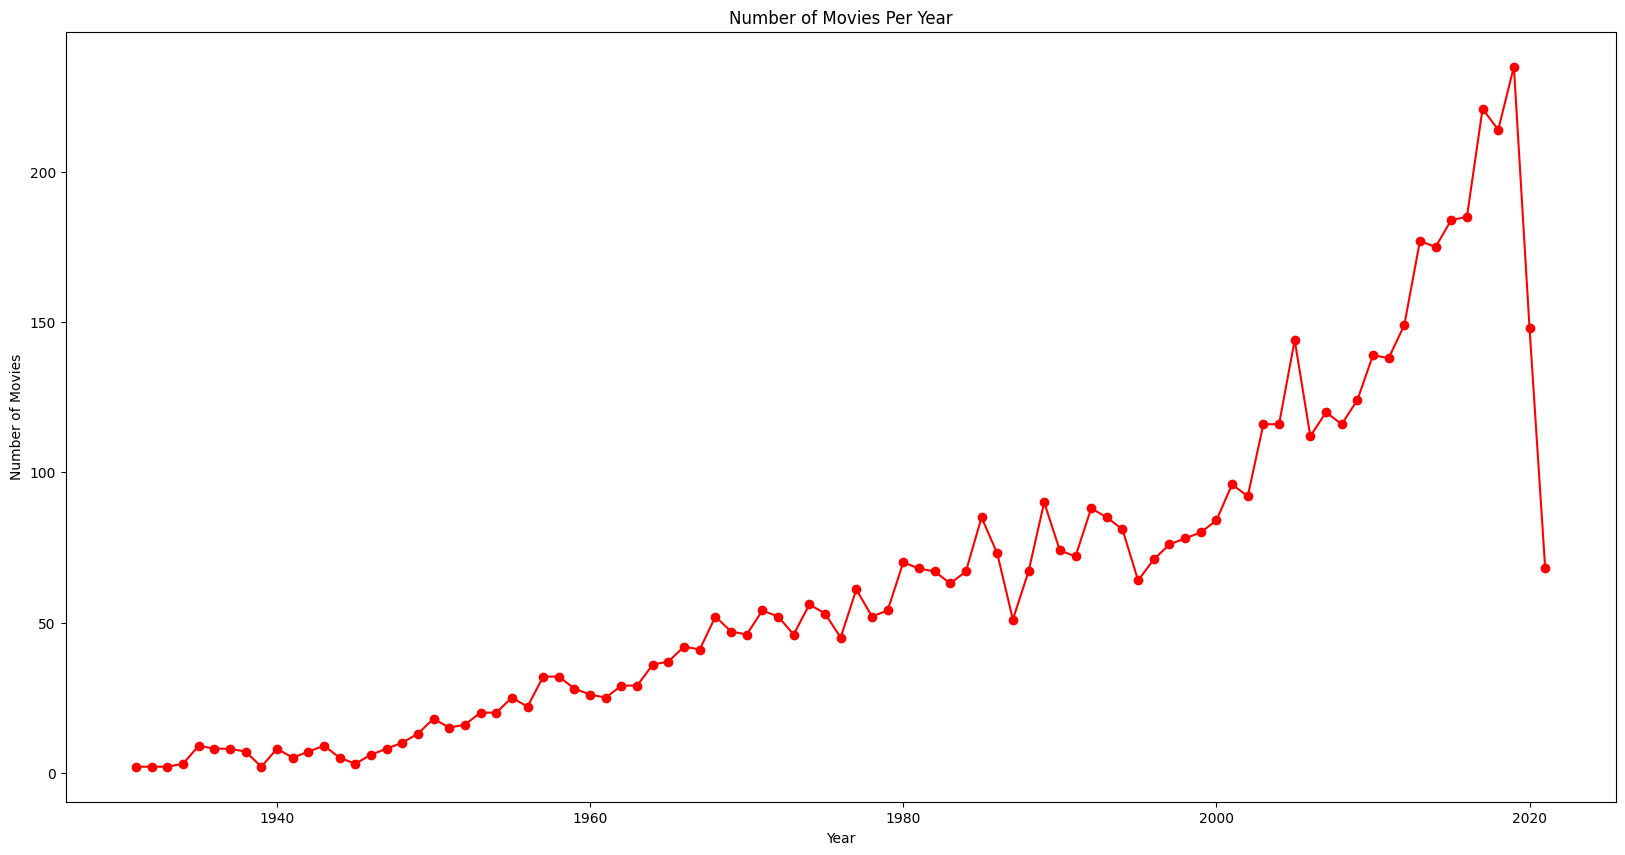

In [107]:
plt.figure(figsize=(20, 10))

year_counts = Data['Year'].value_counts().sort_index()
years = year_counts.index

plt.plot(years, year_counts, marker='o' ,color='red' )

plt.title('Number of Movies Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.show()


In [108]:
genre_mean_rating = Data.groupby('Genre')['Rating'].transform('mean')
Data['Genre_mean_rating'] = genre_mean_rating


In [109]:
Data['Director_encoded'] = Data.groupby('Director')['Rating'].transform('mean')
Data['Actor_encoded'] = Data.groupby('Actor 1')['Rating'].transform('mean')

features = ['Year', 'Votes', 'Duration', 'Genre_mean_rating', 'Director_encoded', 'Actor_encoded']
X = Data[features]
y = Data['Rating']

X['Year'] = X['Year'].astype(int)
X['Votes'] = X['Votes'].astype(str).str.replace(',', '').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = RandomForestRegressor()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R2 Score: {r2 * 100:.2f}%")


Mean Squared Error: 0.4263
Mean Absolute Error: 0.4396
R2 Score: 77.09%


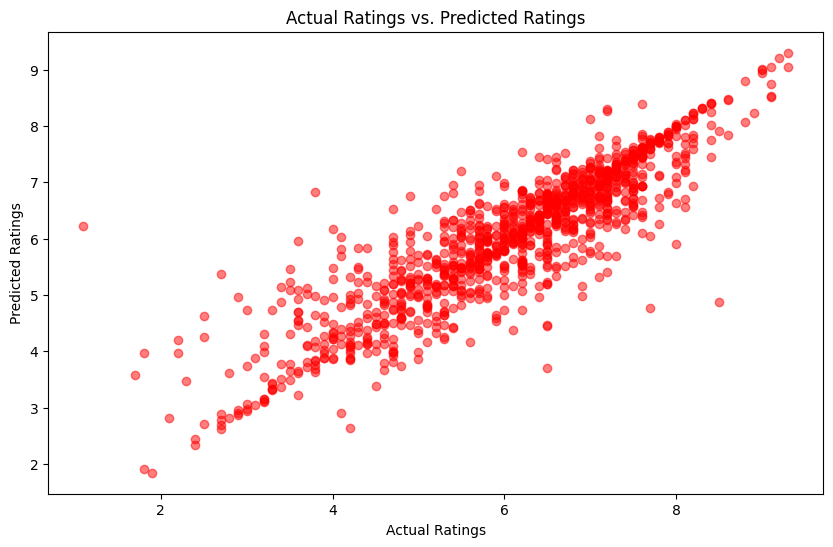

In [110]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5 , color='red')
plt.title('Actual Ratings vs. Predicted Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.show()



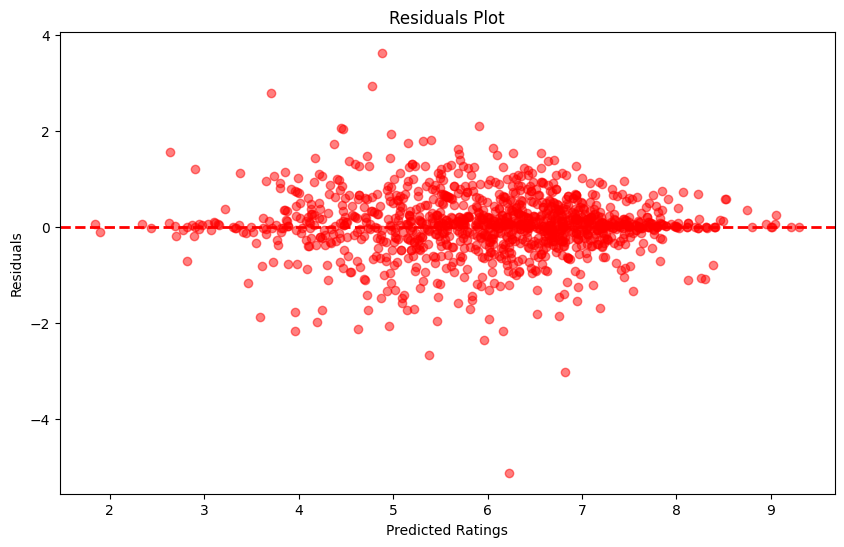

In [111]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5 , color='red')
plt.title('Residuals Plot')
plt.xlabel('Predicted Ratings')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.savefig("Residual Plot.png", dpi=300, bbox_inches='tight')

plt.show()


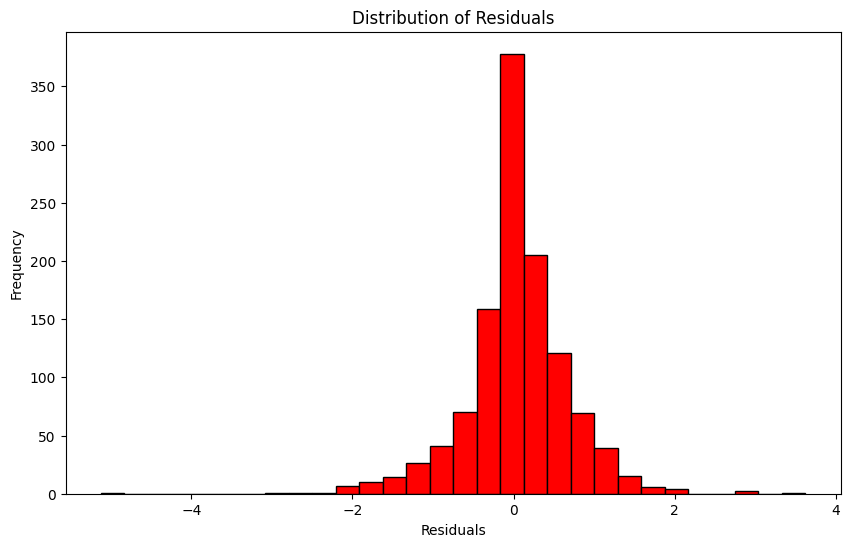

In [112]:

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black' , color='red')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.savefig("Distribution Residuals.png", dpi=300, bbox_inches='tight')

plt.show()

In [113]:
import pickle


genre_means = Data.groupby('Genre')['Genre_mean_rating'].mean().to_dict()
director_means = Data.groupby('Director')['Director_encoded'].mean().to_dict()
actor_means = Data.groupby('Actor 1')['Actor_encoded'].mean().to_dict()

genres = list(Data['Genre'].unique())
directors = list(Data['Director'].unique())
actors = list(Data['Actor 1'].unique())

model_bundle = {
    'model': lr,
    'genre_means': genre_means,
    'director_means': director_means,
    'actor_means': actor_means,
    'genres': genres,
    'directors': directors,
    'actors': actors
}

with open('movie_rating_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Model and encodings saved to movie_rating_model.pkl")

Model and encodings saved to movie_rating_model.pkl
